<a href="https://colab.research.google.com/github/bumsoocoming/AIFFEL_quest_eng/blob/master/NLP/NLP01/Seq2seq%EC%9C%BC%EB%A1%9C_%EB%B2%88%EC%97%AD%EA%B8%B0_%EB%A7%8C%EB%93%A4%EA%B8%B0_%5B%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.makedirs('/content/s2s_translation', exist_ok=True)
print("폴더 생성 완료! ✅")

폴더 생성 완료! ✅


한국어 나눔폰트

In [2]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [90.8 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,608 kB]
Hit:9 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,998 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-se

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


데이터 전처리

In [4]:
# ============================
# 📦 2. 데이터 전처리 - 라이브러리 불러오기
# ============================
# 번역기 프로젝트에 필요한 모든 라이브러리를 한 번에 import!
# 각각 어떤 역할인지 아래 주석 참고 😊

import os                          # 파일/폴더 경로 관련 작업
import re                          # 정규표현식 (텍스트 전처리에 사용)
import urllib.request              # 인터넷에서 데이터 다운로드
import zipfile                     # 압축 파일 (.zip) 풀기
import sentencepiece as spm        # 한국어 포함 토크나이저 (subword 단위 분리)
import pandas as pd                # 데이터프레임으로 데이터 관리
import numpy as np                 # 수치 연산
import torch                       # PyTorch 딥러닝 프레임워크
import torch.nn as nn              # 신경망 레이어 (LSTM, Linear 등)
import torch.optim as optim        # 옵티마이저 (Adam 등)
from torch.nn.utils.rnn import pad_sequence   # 가변 길이 시퀀스 패딩 처리
from sklearn.model_selection import train_test_split  # 학습/테스트 데이터 분리
from torch.utils.data import DataLoader, Dataset      # 배치 학습을 위한 데이터 로더
from tqdm import tqdm              # 학습 진행률 표시 (프로그레스 바)
import random                      # 랜덤 시드 설정 등에 사용

# GPU 사용 가능하면 GPU, 아니면 CPU 사용
# 코랩에서 GPU 설정했으면 "cuda" 출력됨!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)   # PyTorch 버전 확인
print(f"사용 장치: {device}")  # cuda 출력되면 GPU 사용 중 ✅

2.10.0+cu128
사용 장치: cuda


In [5]:
# ============================
# 📥 데이터 다운로드 & 압축 해제
# ============================
# 영어-스페인어 번역 데이터셋을 인터넷에서 다운로드!
# 이미 다운로드된 경우엔 다시 받지 않도록 if문으로 체크함 😊

# 데이터셋 저장할 폴더 경로 설정
# os.path.expanduser() → "~" 같은 홈 경로를 실제 경로로 변환
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")

# 폴더가 없으면 자동으로 생성 (exist_ok=True → 이미 있어도 에러 안 남)
os.makedirs(dataset_dir, exist_ok=True)

# 다운로드할 zip 파일 경로
zip_path = os.path.join(dataset_dir, "spa-eng.zip")

# zip 파일이 없을 때만 다운로드 (중복 다운로드 방지!)
if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    # urlretrieve(url, 저장경로) → URL에서 파일 다운로드
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

# 압축 해제할 폴더 경로
data_folder = os.path.join(dataset_dir, "spa-eng")

# 압축 해제된 폴더가 없을 때만 압축 해제 (중복 방지!)
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    # ZipFile로 zip 열고 → extractall()로 전체 압축 해제
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

# 실제 데이터 파일 경로 (영어-스페인어 문장 쌍)
path_to_file = os.path.join(data_folder, "spa.txt")

# 폴더 안에 어떤 파일이 있는지 확인
print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng.zip', 'spa-eng']


In [6]:
# ============================
# 👀 데이터 확인하기
# ============================
# 다운로드한 spa.txt 파일을 pandas로 읽어서 확인!

# pd.read_csv()로 파일 읽기
# sep="\t"    → 탭(\t)으로 구분된 파일 (영어 \t 스페인어 형태)
# names=["eng", "spa"] → 컬럼 이름을 직접 지정 (파일에 헤더가 없어서!)
df = pd.read_csv(path_to_file, sep="\t", names=["eng", "spa"])

# 상위 5개 행 출력해서 데이터 구조 확인
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


데이터 전처리: 정제하기

In [7]:
# ============================
# 🧹 데이터 전처리 - 문장 정제 함수
# ============================
# 번역 모델 학습 전에 문장을 깔끔하게 정리해주는 함수!
# 노이즈(특수문자, 대문자 등)를 제거해서 모델이 학습하기 좋은 형태로 만들어줌 😊

def preprocess_sentence(sentence):
    # 1️⃣ 소문자로 변환 + 앞뒤 공백 제거
    # "Hello  " → "hello"
    sentence = sentence.lower().strip()

    # 2️⃣ 구두점(?.!,) 앞뒤에 공백 추가
    # "hello?" → "hello ? "
    # 구두점을 별도 토큰으로 분리해서 모델이 인식하기 쉽게 만들어줌!
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 3️⃣ 연속된 공백을 하나로 합치기
    # "hello   world" → "hello world"
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 4️⃣ 영문자와 구두점(?.!,) 외 모든 문자 제거
    # ¡, ¿ 같은 특수문자 → 공백으로 대체
    # 스페인어의 역 물음표(¿), 역 느낌표(¡)도 여기서 제거됨!
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    # 5️⃣ 최종적으로 앞뒤 공백 한 번 더 제거
    sentence = sentence.strip()

    return sentence

print("슝~")  # 함수 정의 완료 확인용!

슝~


In [8]:
# ============================
# ✂️ 데이터 개수 제한 + 전처리 적용
# ============================
# 전체 데이터 중 상위 30,000개만 사용!
# 너무 많은 데이터는 학습 시간이 오래 걸리기 때문에 적당히 줄여줌 😊

# 상위 30,000개 행만 선택
df = df[:30000]

# 영어 문장에 preprocess_sentence 함수 적용
# apply() → 각 행에 함수를 적용해주는 pandas 메서드
df["eng"] = df["eng"].apply(preprocess_sentence)

# 스페인어 문장에도 동일하게 전처리 적용
# lambda x: → preprocess_sentence를 한 번 감싸서 apply에 넣은 것 (결과는 동일!)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

# 전처리 결과 상위 5개 확인
df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


데이터 전처리: 토큰화

In [9]:
# ============================
# 📝 토큰화 준비 - 텍스트 파일 저장
# ============================
# SentencePiece는 텍스트 파일을 입력으로 받아서 Tokenizer를 학습함!
# 그래서 영어/스페인어 문장을 각각 txt 파일로 저장해줘야 해요 😊

# 영어 문장을 한 줄씩 txt 파일로 저장
# index=False  → 행 번호 제외
# header=False → 컬럼명 제외
# sep="\n"     → 각 문장을 줄바꿈으로 구분
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

# 스페인어 문장도 동일하게 저장
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")  # 저장 확인 ✅

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [11]:
# ============================
# 🔤 SentencePiece Tokenizer 학습
# ============================
# 영어(인코더용)와 스페인어(디코더용) Tokenizer를 각각 학습!
# SentencePiece → subword 단위로 쪼개서 희소 문제 해결 😊

# 토큰 설정값 변수로 미리 정의
vocab_size = 3000   # 단어 사전 크기 (3000개의 subword 단위)
pad_id = 0          # <pad> → 문장 길이 맞추기용 패딩 토큰
bos_id = 1          # <start> → 문장 시작 토큰 (Beginning of Sentence)
eos_id = 2          # <end> → 문장 종료 토큰 (End of Sentence)
unk_id = 3          # <unk> → 사전에 없는 모르는 단어 토큰

# 영어 Tokenizer 학습 (인코더용)
# model_prefix="encoder_spm" → encoder_spm.model, encoder_spm.vocab 파일 생성
spm.SentencePieceTrainer.train(
    input="eng_corpus.txt",      # 학습할 영어 텍스트 파일
    model_prefix="encoder_spm",  # 저장될 모델 이름
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)

# 스페인어 Tokenizer 학습 (디코더용)
# model_prefix="decoder_spm" → decoder_spm.model, decoder_spm.vocab 파일 생성
spm.SentencePieceTrainer.train(
    input="spa_corpus.txt",      # 학습할 스페인어 텍스트 파일
    model_prefix="decoder_spm",  # 저장될 모델 이름
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)

print("Tokenizer 학습 완료! ✅")
print("생성된 파일: encoder_spm.model / decoder_spm.model")

Tokenizer 학습 완료! ✅
생성된 파일: encoder_spm.model / decoder_spm.model


In [12]:
# ============================
# 📂 학습된 Tokenizer 불러오기
# ============================
# 앞에서 학습한 Tokenizer 모델 파일을 불러와서 사용할 준비!
# .model 파일을 load() 해야 실제로 문장을 토큰화할 수 있어요 😊

# 인코더용 Tokenizer 불러오기 (영어)
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")   # 영어 모델 파일 로드

# 디코더용 Tokenizer 불러오기 (스페인어)
decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")   # 스페인어 모델 파일 로드

# 잘 불러와졌는지 간단히 테스트!
test_sentence = "hello how are you ?"
encoded = encoder_tokenizer.encode(test_sentence)
print(f"원본 문장: {test_sentence}")
print(f"토큰 ID:  {encoded}")
print(f"다시 복원: {encoder_tokenizer.decode(encoded)}")
print("\nTokenizer 로드 완료! ✅")

원본 문장: hello how are you ?
토큰 ID:  [1286, 8, 74, 31, 7, 9]
다시 복원: hello how are you ?

Tokenizer 로드 완료! ✅


In [13]:
# ============================
# 👀 데이터 샘플 확인
# ============================
# 전처리된 데이터프레임 전체 확인
df

# ============================
# 🔍 특정 샘플 문장 확인
# ============================
# 10000번째 데이터를 뽑아서 전처리가 잘 됐는지 확인!
# SentencePiece는 디코딩 시 <start>, <end> 토큰을 자동으로 처리해줘요 😊

eng_sample = df["eng"][10000]   # 영어 10000번째 문장
spa_sample = df["spa"][10000]   # 스페인어 10000번째 문장

print(eng_sample)   # 영어 문장 출력
print(spa_sample)   # 스페인어 문장 출력

do you like fish ?
te gusta el pescado ?


In [14]:
# ============================
# 🔢 영어 문장 토큰화 + START/END 토큰 추가
# ============================
# 인코더 입력 문장을 숫자 ID로 변환한 뒤
# 앞에 <start>, 뒤에 <end> 토큰을 직접 붙여줌!

# 영어 문장을 토큰 ID 리스트로 변환
enc_token = encoder_tokenizer.encode(eng_sample)

# 앞에 <start>(bos_id=1), 뒤에 <end>(eos_id=2) 수동으로 추가
# bos_id() → Beginning of Sentence ID (=1)
# eos_id() → End of Sentence ID (=2)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]

enc_token   # 토큰 ID 리스트 출력

[1, 27, 7, 39, 324, 9, 2]

In [15]:
# ============================
# 🔄 토큰 ID → 문장으로 복원 (디코딩)
# ============================
# 숫자 ID 리스트를 다시 원래 문장으로 되돌려줌!
# SentencePiece의 decode()는 <start>, <end> 토큰을 자동으로 제거해줘요 😊

enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding   # 복원된 문장 출력

'do you like fish ?'

In [16]:
# ============================
# 📦 번역 데이터셋 클래스 정의
# ============================
# PyTorch Dataset을 상속받아서 번역기에 맞는 데이터셋 클래스 생성!
# DataLoader와 함께 사용하면 배치 단위로 데이터를 불러올 수 있어요 😊

class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data                             # 전체 데이터프레임
        self.encoder_tokenizer = encoder_tokenizer   # 영어 Tokenizer
        self.decoder_tokenizer = decoder_tokenizer   # 스페인어 Tokenizer
        self.max_len = max_len                       # 최대 문장 길이 (이 길이로 통일!)
        self.pad_id = 0   # 패딩 토큰 ID
        self.bos_id = 1   # <start> 토큰 ID
        self.eos_id = 2   # <end> 토큰 ID

    def __len__(self):
        # 전체 데이터 개수 반환 (DataLoader가 내부적으로 호출)
        return len(self.data)

    def __getitem__(self, idx):
        # idx번째 데이터 한 쌍을 가져옴
        src_text = self.data.iloc[idx]['eng']   # 영어 문장 (소스)
        trg_text = self.data.iloc[idx]['spa']   # 스페인어 문장 (타겟)

        # 문장을 토큰 ID 리스트로 변환
        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        # 인코더 입력: 최대 길이로 자르기 (START/END 토큰 불필요)
        src_ids = src_ids[:self.max_len]

        # 디코더 입력: <start> + 문장 + <end>
        # max_len - 2 → <start>, <end> 토큰 자리 2개 미리 확보!
        # ex) max_len=10 → 문장은 최대 8개 토큰만 허용
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]

        # 디코더 라벨: 문장 + <end> (START 토큰 없음!)
        # 모델이 예측해야 할 정답값 → 입력보다 한 칸 앞선 문장
        # ex) 입력: <start> I eat   → 라벨: I eat <end>
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 패딩: max_len보다 짧은 문장 뒤에 <pad>(0) 채우기
        # 모든 문장 길이를 max_len으로 통일해야 배치 처리 가능!
        src_ids   = src_ids   + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        # 텐서로 변환해서 반환
        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [17]:
# ============================
# ✂️ 학습 / 검증 데이터 분리 & DataLoader 생성
# ============================
# 전체 데이터를 80% 훈련 + 20% 검증으로 나누고
# 배치 단위로 불러올 수 있는 DataLoader 생성! 😊

# 하이퍼파라미터 설정
train_ratio = 0.8   # 훈련 데이터 비율 80%
MAX_LEN = 30        # 문장 최대 길이 (30 토큰으로 통일)
BATCH_SIZE = 64     # 한 번에 학습할 문장 쌍 개수

# 전체 데이터에서 80% 랜덤 샘플링 → 훈련 데이터
# random_state=42 → 매번 같은 결과 (재현 가능하도록 시드 고정)
train_data = df.sample(frac=train_ratio, random_state=42)

# 훈련 데이터로 선택되지 않은 나머지 20% → 검증 데이터
valid_data = df.drop(train_data.index)

# 인덱스 초기화 (drop 후 인덱스가 뒤죽박죽이 되므로 재정렬!)
train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

# TranslationDataset으로 변환
# 토큰화 + START/END 토큰 추가 + 패딩이 자동으로 처리됨!
train_data = TranslationDataset(
    train_data,
    encoder_tokenizer,
    decoder_tokenizer,
    max_len=MAX_LEN
)
validation_data = TranslationDataset(
    valid_data,
    encoder_tokenizer,
    decoder_tokenizer,
    max_len=MAX_LEN
)

# DataLoader 생성
# shuffle=True  → 훈련 데이터는 매 에폭마다 순서 섞기 (과적합 방지!)
# shuffle=False → 검증 데이터는 순서 유지 (결과 일관성 유지)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"훈련 데이터: {len(train_data)}개")        # 24,000개
print(f"검증 데이터: {len(validation_data)}개")   # 6,000개
print(f"훈련 배치 수: {len(train_loader)}개")      # 24000 / 64 = 375개
print(f"검증 배치 수: {len(validation_loader)}개") # 6000  / 64 = 94개
print("DataLoader 생성 완료! ✅")

훈련 데이터: 24000개
검증 데이터: 6000개
훈련 배치 수: 375개
검증 배치 수: 94개
DataLoader 생성 완료! ✅


In [18]:
# ============================
# 🔍 DataLoader 배치 shape 확인
# ============================
# DataLoader에서 첫 번째 배치를 꺼내서
# 텐서 shape이 올바른지 확인! 😊

for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break   # 첫 번째 배치만 확인하고 반복 종료!

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


모델 설계

In [19]:
# ============================
# 🎯 Bahdanau Attention 클래스
# ============================
# 디코더가 매 스텝마다 인코더의 어느 부분에 집중할지
# 가중치(attention weight)를 계산해주는 핵심 모듈! 😊

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # 인코더 hidden state를 변환하는 가중치 행렬 (Uₐ)
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        # 디코더 hidden state를 변환하는 가중치 행렬 (Wₐ)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        # 최종 스칼라 점수로 변환하는 벡터 (vₐ)
        # bias=False → 편향 없이 순수 방향성만 학습
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden         : (batch_size, hidden_dim)
        #                   → 디코더의 이전 스텝 hidden state
        # encoder_outputs: (src_len, batch_size, hidden_dim)
        #                   → 인코더의 모든 타임스텝 hidden state

        src_len = encoder_outputs.shape[0]   # 입력 문장 길이

        # 디코더 hidden을 src_len번 복사
        # (batch_size, hidden_dim) → (batch_size, src_len, hidden_dim)
        # 인코더 각 타임스텝과 비교하기 위해 길이 맞춰줌!
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        # 인코더 출력 shape 변환
        # (src_len, batch_size, hidden_dim) → (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # Attention Score 계산 (Bahdanau 수식)
        # eᵢⱼ = vᵀ tanh(W1 * hⱼ + W2 * sᵢ₋₁)
        # (batch_size, src_len, hidden_dim)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))

        # 스칼라 점수로 변환
        # (batch_size, src_len, hidden_dim) → (batch_size, src_len)
        attention = self.v(energy).squeeze(2)

        # Softmax로 확률값(가중치)으로 변환
        # 모든 타임스텝의 가중치 합 = 1
        # αᵢⱼ = softmax(eᵢⱼ)
        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [20]:
# ============================
# 📥 Encoder 클래스
# ============================
# 입력 문장(영어)을 읽어서
# 모든 타임스텝의 hidden state와 마지막 hidden state를 출력!
# 마지막 hidden state → 디코더의 초기 hidden state로 전달 😊

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        # input_dim  : 영어 단어 사전 크기 (vocab_size)
        # emb_dim    : 임베딩 벡터 차원
        # hidden_dim : GRU hidden state 차원
        super().__init__()

        # 토큰 ID → 임베딩 벡터로 변환
        self.embedding = nn.Embedding(input_dim, emb_dim)

        # GRU : 임베딩 벡터를 받아서 hidden state 생성
        # batch_first=False (기본값) → (seq_len, batch, feature) 형태
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size) ← 영어 토큰 ID 시퀀스

        # 토큰 ID → 임베딩 벡터
        embedded = self.embedding(src)
        # embedded : (src_len, batch_size, emb_dim)

        # GRU 실행
        # outputs : 모든 타임스텝의 hidden state
        # hidden  : 마지막 타임스텝의 hidden state (디코더 초기값으로 사용!)
        outputs, hidden = self.rnn(embedded)
        # outputs : (src_len, batch_size, hidden_dim)
        # hidden  : (1, batch_size, hidden_dim)

        return outputs, hidden

In [21]:
# ============================
# 📤 Decoder 클래스 (교재 버전)
# ============================
# 이전 버전과 다른 핵심 차이점:
# GRU 입력 = 임베딩만! (context vector는 GRU 이후 출력층에서 결합)
# fc_out 입력 = hidden state + context vector 합쳐서 예측! 😊

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        # output_dim : 스페인어 단어 사전 크기
        # emb_dim    : 임베딩 벡터 차원
        # hidden_dim : GRU hidden state 차원
        # attention  : BahdanauAttention 객체 (외부에서 주입!)
        super(Decoder, self).__init__()
        self.output_dim = output_dim
        self.attention = attention

        # 토큰 ID → 임베딩 벡터
        self.embedding = nn.Embedding(output_dim, emb_dim)

        # ⭐ GRU 입력 = 임베딩만! (emb_dim)
        # context vector는 GRU 이후에 결합하는 구조!
        self.rnn = nn.GRU(emb_dim, hidden_dim)

        # ⭐ 출력층 입력 = hidden state + context vector
        # hidden_dim + hidden_dim = hidden_dim * 2
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input          : (batch_size,) ← 현재 타임스텝 입력 토큰
        # hidden         : (1, batch_size, hidden_dim) ← 이전 hidden state
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        # 1️⃣ 배치 차원 추가
        input = input.unsqueeze(0)
        # input : (1, batch_size)

        # 2️⃣ 임베딩 변환
        embedded = self.embedding(input)
        # embedded : (1, batch_size, emb_dim)

        # 3️⃣ Attention 가중치 계산
        # hidden[-1] → 마지막 레이어 hidden state (batch_size, hidden_dim)
        # encoder_outputs → 인코더 모든 타임스텝 hidden state
        a = self.attention(hidden[-1], encoder_outputs)
        # a : (batch_size, src_len) ← 각 인코더 토큰의 중요도!

        # 4️⃣ Context Vector 계산
        # a unsqueeze → (batch_size, 1, src_len)
        a = a.unsqueeze(1)

        # encoder_outputs permute → (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # 행렬 곱으로 가중 평균 계산
        # (batch_size, 1, src_len) x (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)
        # context : (batch_size, 1, hidden_dim)

        context = context.permute(1, 0, 2)
        # context : (1, batch_size, hidden_dim)

        # 5️⃣ GRU 실행 (임베딩만 입력!)
        output, hidden = self.rnn(embedded, hidden)
        # output : (1, batch_size, hidden_dim)
        # hidden : (1, batch_size, hidden_dim)

        # 6️⃣ 출력층: hidden state + context vector 결합해서 예측
        output = output.squeeze(0)    # (batch_size, hidden_dim)
        context = context.squeeze(0)  # (batch_size, hidden_dim)

        # hidden + context 이어붙여서 단어 예측
        # (batch_size, hidden_dim + hidden_dim) → (batch_size, output_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))

        return prediction, hidden, a.squeeze(1)

In [23]:
# ============================
# 🤝 Seq2Seq + Attention 전체 모델
# ============================
# Encoder + Decoder + Attention을 하나로 합친 최종 모델!
# 학습 모드(trg 있음)와 추론 모드(trg 없음)를 모두 처리해요 😊

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder   # 인코더 모듈
        self.decoder = decoder   # 디코더 모듈
        self.device = device     # CPU or GPU

    def forward(self, src, trg=None, max_len=30, bos_id=1, eos_id=2):
        # src    : (src_len, batch_size) ← 영어 입력 문장
        # trg    : (trg_len, batch_size) ← 스페인어 정답 (학습시에만 존재!)
        # max_len: 추론 시 최대 생성 길이
        # bos_id : <start> 토큰 ID
        # eos_id : <end> 토큰 ID

        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트로 저장
        outputs = []

        # Attention Map 시각화를 위해 가중치 저장
        attentions = []

        # ① 인코더 실행
        # encoder_outputs : (src_len, batch_size, hidden_dim) ← 모든 타임스텝
        # hidden          : (1, batch_size, hidden_dim) ← 마지막 hidden state
        encoder_outputs, hidden = self.encoder(src)

        # ============================
        # 🏋️ 학습 모드 (trg 있음)
        # ============================
        if trg is not None:
            for t in range(0, trg.shape[0]):
                # 정답 토큰을 디코더 입력으로 사용 (Teacher Forcing!)
                # 매 스텝마다 실제 정답을 입력으로 줘서 학습 안정화
                input = trg[t]   # (batch_size,)

                output, hidden, attention = self.decoder(
                    input, hidden, encoder_outputs
                )
                # output    : (batch_size, output_dim)
                # hidden    : (1, batch_size, hidden_dim)
                # attention : (batch_size, src_len)

                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        # ============================
        # 🔍 추론 모드 (trg 없음)
        # ============================
        else:
            # 추론 시엔 정답이 없으므로 <start> 토큰으로 시작!
            input = torch.full(
                (batch_size,), bos_id,
                dtype=torch.long,
                device=self.device
            )   # (batch_size,) ← 모든 배치에 <start> 토큰

            # 각 배치별로 <end> 토큰 생성 여부 추적
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(
                    input, hidden, encoder_outputs
                )
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                # 가장 높은 확률의 단어 선택 → 다음 스텝 입력으로 사용
                top1 = output.argmax(1)   # (batch_size,)
                input = top1

                # <end> 토큰 생성한 배치 체크
                finished |= (top1 == eos_id)

                # 모든 배치가 <end> 생성하면 조기 종료!
                if finished.all():
                    break

        # 리스트 → 텐서로 변환
        outputs = torch.cat(outputs, dim=0)
        # outputs    : (trg_len, batch_size, output_dim)

        attentions = torch.cat(attentions, dim=0)
        # attentions : (trg_len, batch_size, src_len)

        return outputs, attentions

In [24]:
# ============================
# ⚙️ 모델 하이퍼파라미터 설정
# ============================
# 모델을 만들기 전에 필요한 설정값들을 먼저 정의! 😊

# GPU 사용 가능하면 GPU, 아니면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")   # cuda 출력되면 GPU 사용 중 ✅

# 인코더 입력 차원 = 영어 단어 사전 크기
input_dim = len(encoder_tokenizer)   # 3000

# 디코더 출력 차원 = 스페인어 단어 사전 크기
output_dim = len(decoder_tokenizer)  # 3000

# 임베딩 벡터 차원 (토큰 ID → 벡터 변환 크기)
emb_dim = 256

# GRU hidden state 차원 (모델의 기억 용량!)
hid_dim = 512

print(f"input_dim  (영어 vocab 크기) : {input_dim}")
print(f"output_dim (스페인어 vocab 크기) : {output_dim}")
print(f"emb_dim    (임베딩 차원) : {emb_dim}")
print(f"hid_dim    (hidden 차원) : {hid_dim}")

사용 장치: cuda
input_dim  (영어 vocab 크기) : 3000
output_dim (스페인어 vocab 크기) : 3000
emb_dim    (임베딩 차원) : 256
hid_dim    (hidden 차원) : 512


In [25]:
# ============================
# 🏗️ 모델 조립하기
# ============================
# Encoder, Attention, Decoder를 각각 만들고
# Seq2SeqAttention으로 하나로 합쳐줘요! 😊

# 1️⃣ 인코더 생성
# 영어 문장을 읽어서 hidden state 생성
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)

# 2️⃣ Bahdanau Attention 생성
# 디코더가 매 스텝마다 인코더의 어느 부분에 집중할지 결정
attention = BahdanauAttention(hid_dim).to(device)

# 3️⃣ 디코더 생성
# attention 객체를 주입받아서 내부에서 사용!
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)

# 4️⃣ 최종 Seq2Seq 모델 조립
# Encoder + Decoder + Attention을 하나로 합친 완성본!
model = Seq2SeqAttention(encoder, decoder, device).to(device)

# 모델 구조 확인
print(model)
print(f"\n학습 가능한 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}개")

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)

학습 가능한 파라미터 수: 7,502,264개


In [26]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


훈련하기

Optimizer & Loss

In [27]:
# ============================
# ⚙️ (1) Optimizer & Loss 설정
# ============================

# 옵티마이저 설정
# Adam → 가장 널리 쓰이는 옵티마이저!
# model.parameters() → 인코더 + 디코더 + 어텐션 파라미터 한번에 전달
# lr=1e-3 → 학습률 (얼마나 빠르게 정답을 찾아갈지)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Loss 함수 설정
# CrossEntropyLoss → 모델 출력 확률분포와 정수 인덱스 정답을 비교!
# ignore_index=pad_id → <PAD> 토큰(ID=0)에 대한 Loss는 계산하지 않음!
# ⭐ 이게 없으면 모델이 <PAD>만 뱉는 망한 모델이 될 수 있어요!
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [28]:
# ============================
# 🏋️ (2) train_step 함수
# ============================
# 한 에폭 동안 전체 학습 데이터를 돌면서
# Loss를 계산하고 모델 파라미터를 업데이트하는 함수! 😊

def train_step(model, data_loader, optimizer, criterion, epoch):

    # 학습 모드 활성화
    # Dropout, BatchNorm 등이 학습 모드로 동작하게 됨
    model.train()

    epoch_loss = 0   # 에폭 전체 Loss 누적용

    # tqdm → 학습 진행률을 프로그레스 바로 보여줌!
    # desc=f"Epoch {epoch+1}" → 현재 에폭 번호 표시
    # leave=True → 완료 후에도 프로그레스 바 유지
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:

        # DataLoader는 (batch, seq_len) 형태로 반환
        # 모델 입력은 (seq_len, batch) 형태 필요 → permute로 변환!
        src       = src.permute(1, 0).to(device)        # (src_len, batch_size)
        trg_input = trg_input.permute(1, 0).to(device)  # (trg_len, batch_size)
        trg_label = trg_label.permute(1, 0).to(device)  # (trg_len, batch_size)

        # ① 이전 배치의 gradient 초기화 (누적 방지!)
        optimizer.zero_grad()

        # ② 모델 Forward (학습 모드 → trg_input 전달)
        # outputs : (trg_len, batch_size, output_dim)
        # _       : attentions (학습 시엔 사용 안 함)
        outputs, _ = model(src, trg_input)

        # ③ Loss 계산을 위해 shape 변환
        # CrossEntropyLoss 입력 형식:
        # 예측값 → (N, output_dim)
        # 정답값 → (N,)
        outputs   = outputs.reshape(-1, outputs.shape[-1])
        # (trg_len * batch_size, output_dim)
        trg_label = trg_label.reshape(-1)
        # (trg_len * batch_size,)

        # ④ Loss 계산 (PAD 토큰은 자동으로 무시!)
        loss = criterion(outputs, trg_label)

        # ⑤ Backpropagation (gradient 계산)
        loss.backward()

        # ⑥ Gradient Clipping
        # gradient가 너무 커지는 Exploding Gradient 방지!
        # max_norm=1 → gradient의 norm이 1을 넘으면 잘라냄
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        # ⑦ 파라미터 업데이트
        optimizer.step()

        # Loss 누적 & 프로그레스 바에 현재 Loss 표시
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    # 에폭 평균 Loss 반환
    return epoch_loss / len(data_loader)

print("슝~")

슝~


In [29]:
# ============================
# 🧪 eval_step 함수
# ============================
# 검증 데이터로 모델 성능을 평가하는 함수!
# 학습(train_step)과 거의 동일하지만
# gradient 계산 X, 파라미터 업데이트 X 가 핵심! 😊

def eval_step(model, data_loader, optimizer, criterion):

    # 평가 모드 활성화
    # Dropout 비활성화, BatchNorm 고정 등
    # ⭐ 평가 중엔 절대 학습이 일어나면 안 됨!
    model.eval()

    total_loss = 0   # 전체 Loss 누적용

    # torch.no_grad() → gradient 계산 완전 차단!
    # 메모리 절약 + 연산 속도 향상 😊
    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc=f"Validation", leave=True)

        for src, trg_input, trg_label in progress_bar:

            # (batch, seq_len) → (seq_len, batch) 변환
            src       = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            # Forward (평가 모드 → trg_input 전달)
            # gradient 계산 없이 예측만 수행!
            outputs, _ = model(src, trg_input)

            # Loss 계산을 위해 shape 변환
            outputs   = outputs.reshape(-1, outputs.shape[-1])
            # (trg_len * batch_size, output_dim)
            trg_label = trg_label.reshape(-1)
            # (trg_len * batch_size,)

            # Loss 계산 (PAD 토큰 무시!)
            loss = criterion(outputs, trg_label)
            total_loss += loss.item()

            progress_bar.set_postfix({"Test Loss": f"{loss.item():.4f}"})

    # 평균 Loss 반환
    return total_loss / len(data_loader)

print("슝~")

슝~


In [30]:
# ============================
# 🚀 (3) 훈련 시작하기
# ============================
# train_step + eval_step을 EPOCHS만큼 반복!
# 매 에폭마다 훈련 Loss와 검증 Loss를 함께 확인 😊

EPOCHS = 10

train_loss_history = []   # 훈련 Loss 기록
valid_loss_history = []   # 검증 Loss 기록

for epoch in range(EPOCHS):

    # ① 훈련
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)

    # ② 검증 (학습 없이 성능만 평가!)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)

    # Loss 기록
    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")

print("\n훈련 완료! ✅")

Validation: 100%|██████████| 94/94 [00:04<00:00, 23.30it/s, Test Loss=2.1371]


Epoch 1/10 | Train Loss: 3.0850 | Valid Loss: 2.1214


Validation: 100%|██████████| 94/94 [00:03<00:00, 23.70it/s, Test Loss=1.5518]


Epoch 2/10 | Train Loss: 1.5393 | Valid Loss: 1.6307


Validation: 100%|██████████| 94/94 [00:04<00:00, 23.26it/s, Test Loss=1.4472]


...

Epoch 8/10 | Train Loss: 0.2208 | Valid Loss: 1.6555


Validation: 100%|██████████| 94/94 [00:04<00:00, 22.61it/s, Test Loss=1.7404]


Epoch 9/10 | Train Loss: 0.2079 | Valid Loss: 1.6964


Validation: 100%|██████████| 94/94 [00:04<00:00, 21.37it/s, Test Loss=1.7468]

Epoch 10/10 | Train Loss: 0.2025 | Valid Loss: 1.7220

훈련 완료! ✅


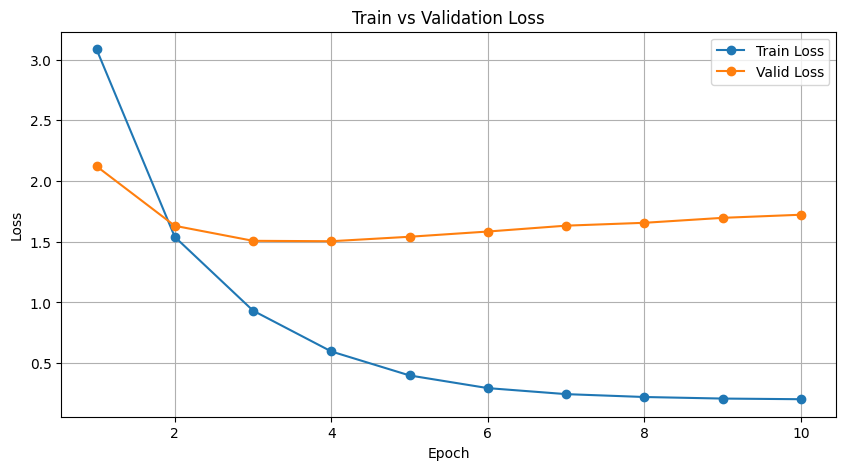

In [31]:
# ============================
# 📊 Loss 시각화
# ============================
# 훈련/검증 Loss가 잘 줄어들고 있는지 그래프로 확인! 😊

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_loss_history, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), valid_loss_history, label='Valid Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# ============================
# 🚀 훈련 시작! (20 에폭)
# ============================
# %%time → 전체 훈련 시간 자동 측정!
# 20 에폭 동안 훈련 + 검증을 반복 😊

%%time
EPOCHS = 20

for epoch in range(EPOCHS):

    # ① 훈련 (파라미터 업데이트 O)
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)

    # ② 검증 (파라미터 업데이트 X, 성능만 평가)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)

    # 에폭별 결과 출력
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Validation: 100%|██████████| 94/94 [00:03<00:00, 23.52it/s, Test Loss=1.7355]


Epoch 1/20, Train Loss: 0.2003, Validation Loss: 1.7535


Validation: 100%|██████████| 94/94 [00:04<00:00, 22.44it/s, Test Loss=1.7617]


Epoch 2/20, Train Loss: 0.1991, Validation Loss: 1.7740


Validation: 100%|██████████| 94/94 [00:04<00:00, 21.79it/s, Test Loss=1.8006]


...

Epoch 18/20, Train Loss: 0.1735, Validation Loss: 1.9446


Validation: 100%|██████████| 94/94 [00:04<00:00, 21.44it/s, Test Loss=2.0532]


Epoch 19/20, Train Loss: 0.1716, Validation Loss: 1.9546


Validation: 100%|██████████| 94/94 [00:04<00:00, 22.23it/s, Test Loss=2.0378]

Epoch 20/20, Train Loss: 0.1724, Validation Loss: 1.9588
CPU times: user 15min 5s, sys: 8.57 s, total: 15min 14s
Wall time: 15min 24s


In [33]:
# ============================
# 🔍 번역 평가 함수
# ============================
# 학습된 모델로 실제 영어 문장을 스페인어로 번역!
# Attention Map 시각화를 위한 가중치도 함께 반환 😊

def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):

    # 평가 모드 (Dropout 비활성화, gradient 계산 X)
    model.eval()

    # ① 입력 문장 전처리
    # 소문자 변환 + 구두점 분리 + 특수문자 제거
    sentence = preprocess_sentence(sentence)

    # ② 문장 → 토큰 ID 변환
    src_ids = encoder_tokenizer.encode(sentence)

    # ③ 최대 길이로 자르기
    src_ids = src_ids[:max_len]

    # ④ 패딩 추가 (max_len 길이로 통일)
    src_ids = src_ids + [0] * (max_len - len(src_ids))

    # ⑤ 텐서 변환 + 배치 차원 추가
    # unsqueeze(1) → (src_len,) → (src_len, 1) 배치 크기 1로!
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    # ⑥ 추론 실행 (trg 없이 → 추론 모드!)
    # outputs    : (trg_len, 1, output_dim)
    # attentions : (trg_len, 1, src_len)
    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    # ⑦ 가장 높은 확률의 단어 ID → 스페인어 단어로 디코딩
    # outputs.argmax(2) → 각 타임스텝에서 가장 높은 확률 단어 ID
    # squeeze(1)        → 배치 차원 제거
    result = [
        decoder_tokenizer.decode([token.item()])
        for token in outputs.argmax(2).squeeze(1)
    ]

    # ⑧ <end> 토큰 등장 전까지만 결과 사용
    # <end> 이후는 의미 없는 토큰이므로 잘라냄!
    if "<end>" in result:
        result = result[:result.index("<end>")]

    # 번역 결과, 전처리된 입력 문장, attention 가중치 반환
    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [34]:
# ============================
# 🌍 번역 테스트해보기!
# ============================

test_sentences = [
    "I love you.",
    "How are you?",
    "Where is the restaurant?",
    "She is very beautiful."
]

for sentence in test_sentences:
    result, src, _ = evaluate(
        sentence, model,
        encoder_tokenizer,
        decoder_tokenizer
    )
    print(f"영어  : {src}")
    print(f"스페인어: {' '.join(result)}")
    print("-" * 40)

영어  : i love you .
스페인어: os amo . 
----------------------------------------
영어  : how are you ?
스페인어: cu nto s est n ? 
----------------------------------------
영어  : where is the restaurant ?
스페인어: d nde est el re s to ? 
----------------------------------------
영어  : she is very beautiful .
스페인어: es mu y hermosa . 
----------------------------------------


영어    : i love you .
스페인어 : os amo . 


/tmp/ipykernel_952/2949498002.py:28: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2949498002.py:28: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2949498002.py:28: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2949498002.py:28: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2949498002.py:28: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2949498002.py:28: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2949498002.py:28: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

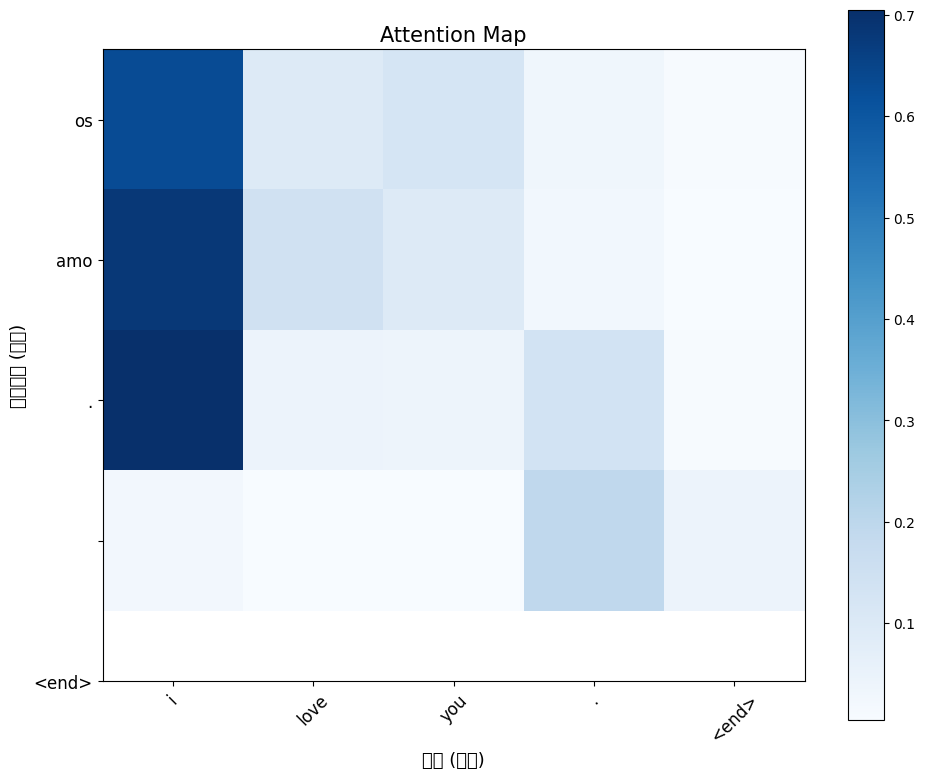

In [35]:
# ============================
# 🗺️ 보너스: Attention Map 시각화
# ============================
# 어느 영어 단어에 집중해서 스페인어를 번역했는지
# Heat Map으로 확인! 😊

def plot_attention(sentence, result, attentions):
    src_tokens = sentence.split() + ['<end>']
    trg_tokens = result + ['<end>']

    # attentions : (trg_len, src_len)
    attention_map = attentions[:len(trg_tokens), :len(src_tokens)]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attention_map, cmap='Blues')

    # 축 레이블 설정
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(trg_tokens)))
    ax.set_xticklabels(src_tokens, fontsize=12, rotation=45)
    ax.set_yticklabels(trg_tokens, fontsize=12)

    ax.set_xlabel('영어 (입력)', fontsize=13)
    ax.set_ylabel('스페인어 (출력)', fontsize=13)
    ax.set_title('Attention Map', fontsize=15)

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

# 테스트
sentence = "I love you ."
result, src, attentions = evaluate(
    sentence, model,
    encoder_tokenizer,
    decoder_tokenizer
)
print(f"영어    : {src}")
print(f"스페인어 : {' '.join(result)}")
plot_attention(src, result, attentions)

In [36]:
# ============================
# 🗺️ Attention Map 시각화 함수
# ============================
# 번역 시 영어 각 단어에 얼마나 집중했는지
# 색깔로 시각화해주는 함수! 😊
# 밝을수록 높은 Attention 가중치 = 더 집중한 단어!

def plot_attention(attention, sentence, predicted_sentence):

    fig, ax = plt.subplots(figsize=(10, 10))

    # attention 행렬을 색깔 맵으로 시각화
    # viridis → 어두운 보라(낮음) ~ 밝은 노랑(높음) 색상
    ax.matshow(attention, cmap='viridis')

    # 폰트 크기 설정
    fontdict = {'fontsize': 14}

    # x축 → 영어 입력 문장 토큰
    # rotation=90 → 단어가 겹치지 않게 세로로 표시
    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    # y축 → 스페인어 출력 문장 토큰
    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    ax.set_xlabel('영어 입력 문장', fontsize=13)
    ax.set_ylabel('스페인어 번역 결과', fontsize=13)
    ax.set_title('Attention Map 시각화', fontsize=15)

    plt.tight_layout()
    plt.show()

영어    : i love you .
스페인어 : os amo . 
----------------------------------------


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

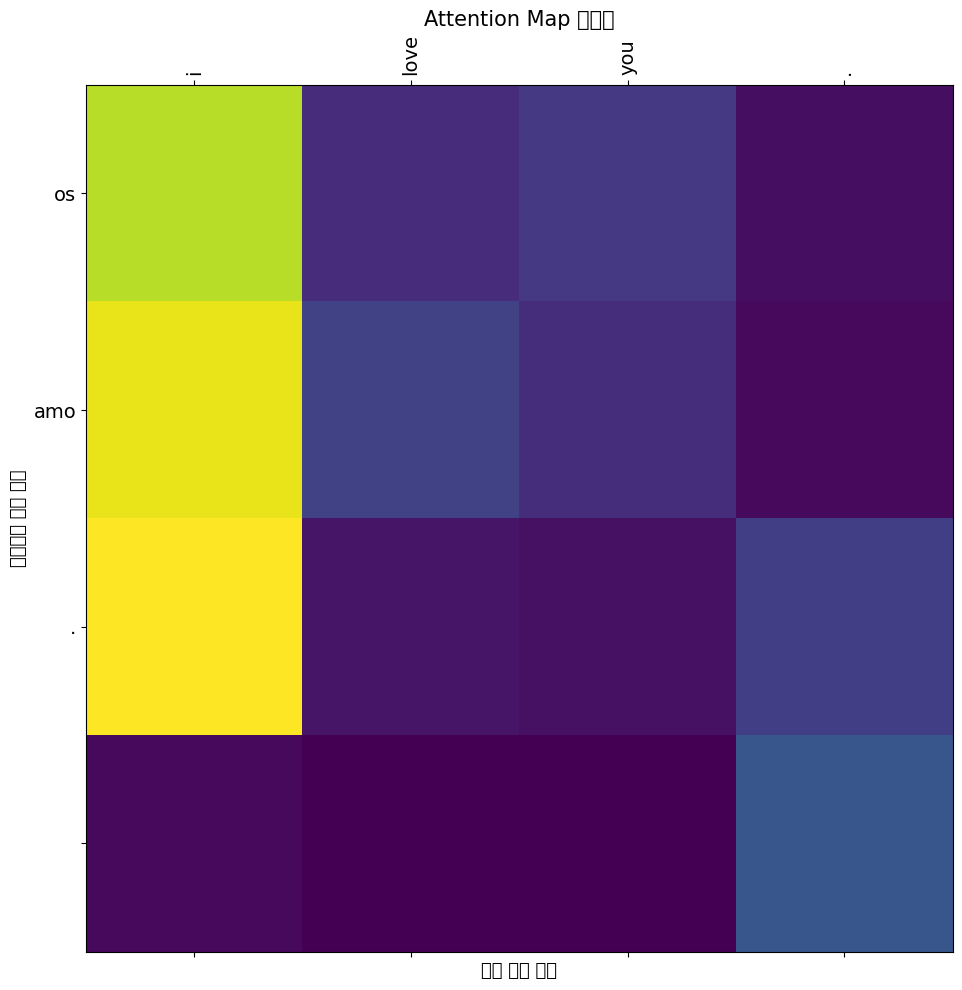

영어    : how are you ?
스페인어 : cu nto s est n ? 
----------------------------------------


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

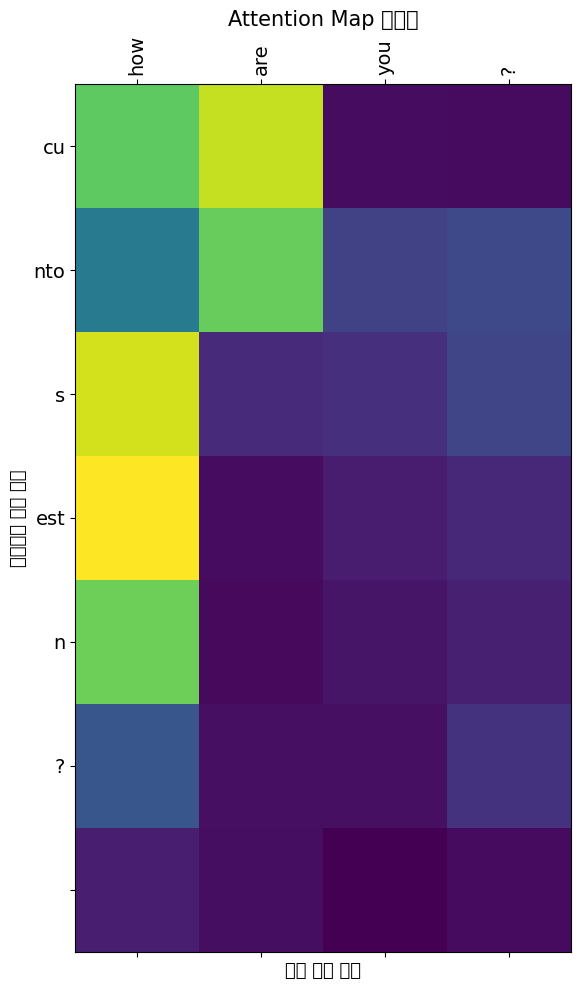

영어    : she is very beautiful .
스페인어 : es mu y hermosa . 
----------------------------------------


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

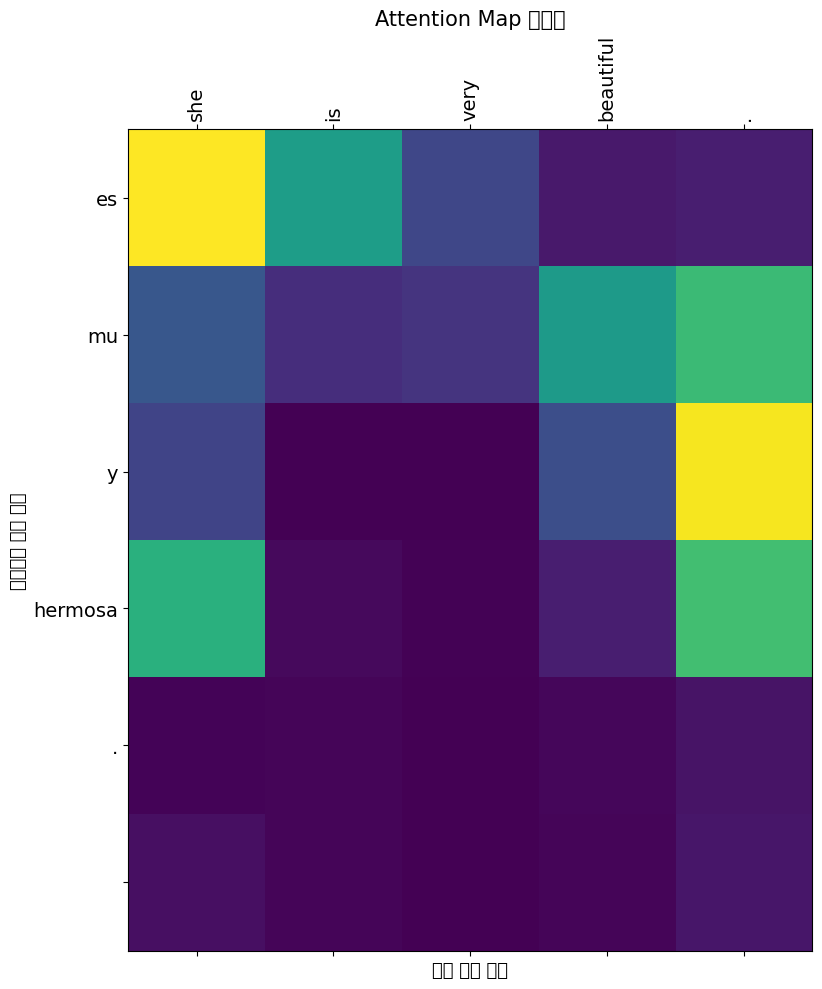

In [37]:
# ============================
# 🌍 번역 + Attention Map 한번에 확인!
# ============================

def translate_and_plot(sentence):
    # 번역 실행
    result, src, attentions = evaluate(
        sentence, model,
        encoder_tokenizer,
        decoder_tokenizer
    )

    print(f"영어    : {src}")
    print(f"스페인어 : {' '.join(result)}")
    print("-" * 40)

    # Attention Map 시각화
    # attentions shape : (trg_len, src_len)
    # 출력 길이만큼 자르기
    src_tokens  = src.split()
    trg_tokens  = result

    attention_map = attentions[:len(trg_tokens), :len(src_tokens)]

    plot_attention(attention_map, src_tokens, trg_tokens)

# 테스트 문장으로 확인!
translate_and_plot("I love you .")
translate_and_plot("How are you ?")
translate_and_plot("She is very beautiful .")

In [38]:
# ============================
# 🌍 번역 + Attention Map 통합 함수
# ============================
# evaluate() + plot_attention() 을 하나로 합친 최종 번역 함수!
# 번역 결과 출력 + Attention Map 시각화까지 한번에! 😊

def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):

    # ① evaluate() 로 번역 실행
    # result    : 번역된 스페인어 토큰 리스트
    # sentence  : 전처리된 영어 입력 문장
    # attention : (trg_len, src_len) Attention 가중치
    result, sentence, attention = evaluate(
        sentence, model,
        encoder_tokenizer,
        decoder_tokenizer,
        max_len
    )

    # ② 번역 결과 출력
    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # ③ Attention Map 크기 조정
    # 실제 출력 길이 x 실제 입력 길이 만큼만 잘라냄
    # 나머지는 <pad> 토큰이라 의미 없음!
    attention = attention[:len(result), :len(sentence.split())]

    # ④ Attention Map 시각화
    plot_attention(attention, sentence.split(), result)

Input: i love you .
Predicted translation: ['os', 'amo', '.', '']


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

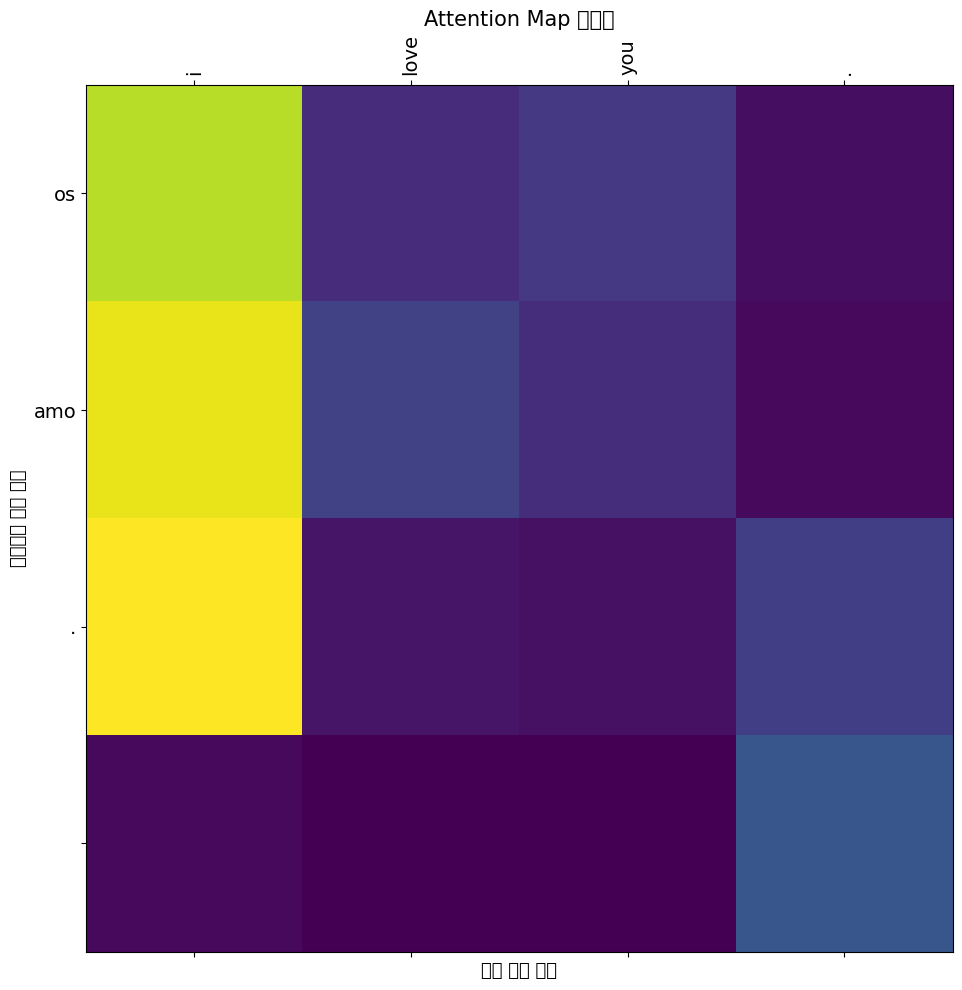

Input: how are you ?
Predicted translation: ['cu', 'nto', 's', 'est', 'n', '?', '']


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

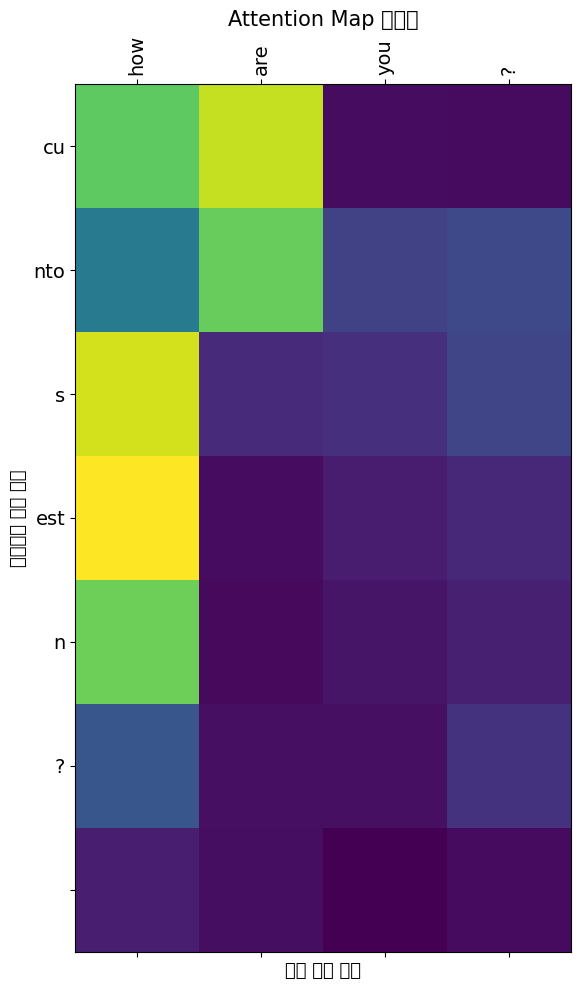

Input: she is beautiful .
Predicted translation: ['es', 'guap', 'a', '.', '']


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

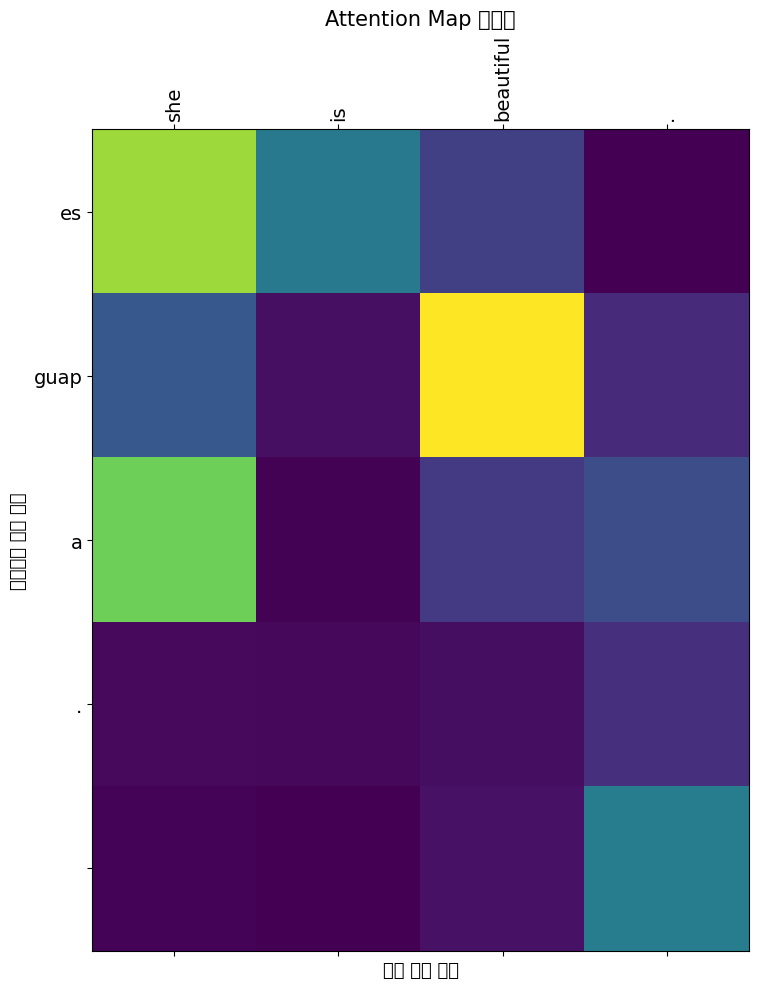

Input: i am a student .
Predicted translation: ['s', 'oy', 'un', 'estudiante', '.', '']


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

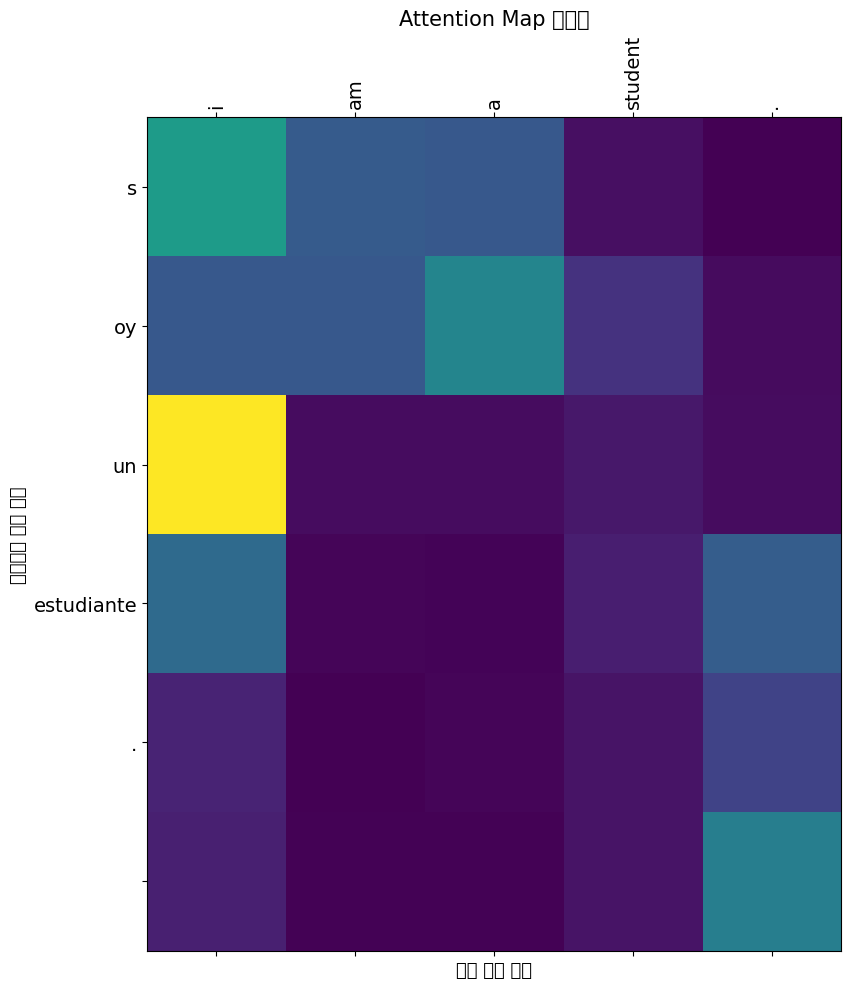

In [39]:
# ============================
# ✅ 실제로 번역해보기!
# ============================

# 다양한 문장으로 테스트해보세요 😊
translate("I love you .",        model, encoder_tokenizer, decoder_tokenizer)
translate("How are you ?",       model, encoder_tokenizer, decoder_tokenizer)
translate("She is beautiful .",  model, encoder_tokenizer, decoder_tokenizer)
translate("I am a student .",    model, encoder_tokenizer, decoder_tokenizer)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'tel', 'fono', 'se', 'ha', 'ido', '.', '']


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

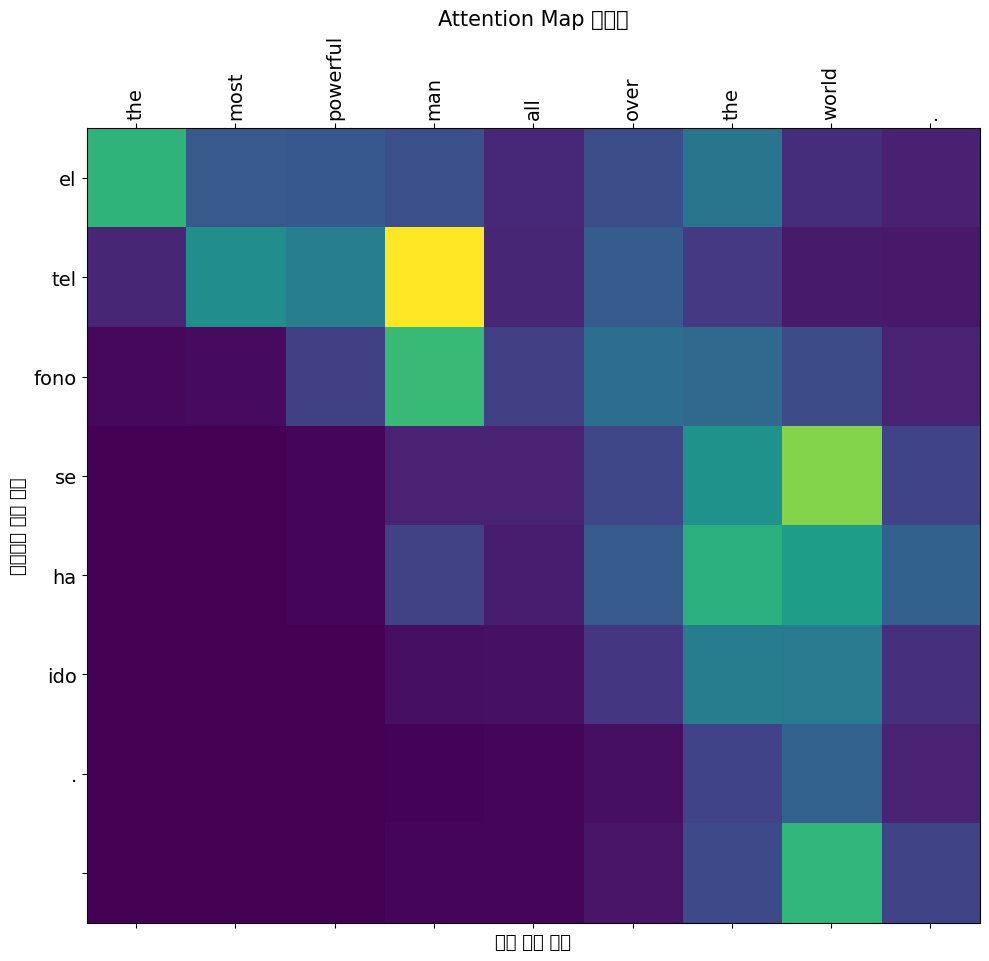

In [40]:
# ============================
# 🌍 번역 테스트!
# ============================
# 학습된 모델로 실제 번역 성능 확인해보기 😊

translate(
    "The most powerful man all over the world.",
    model,
    encoder_tokenizer,
    decoder_tokenizer,
    max_len=30
)

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', 'te', '?', '']


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

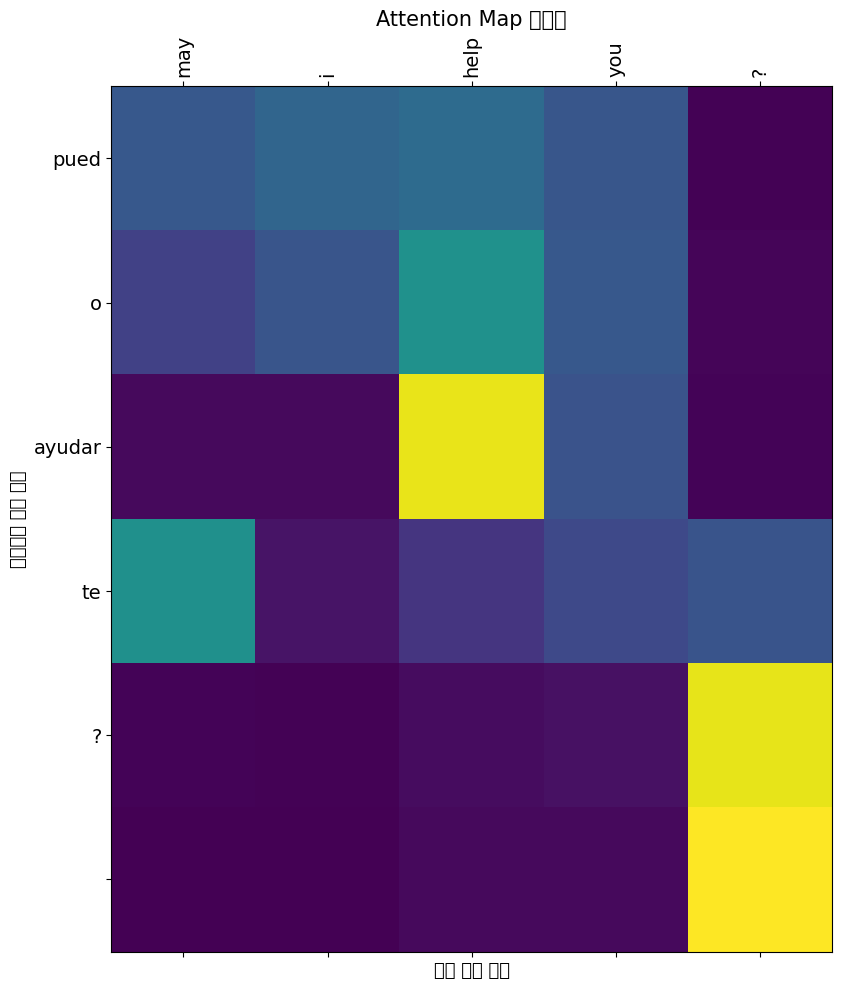

In [41]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['me', 'da', 's', 'c', 'af', 'c', 'af', '?', '']


/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/3598332516.py:32: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

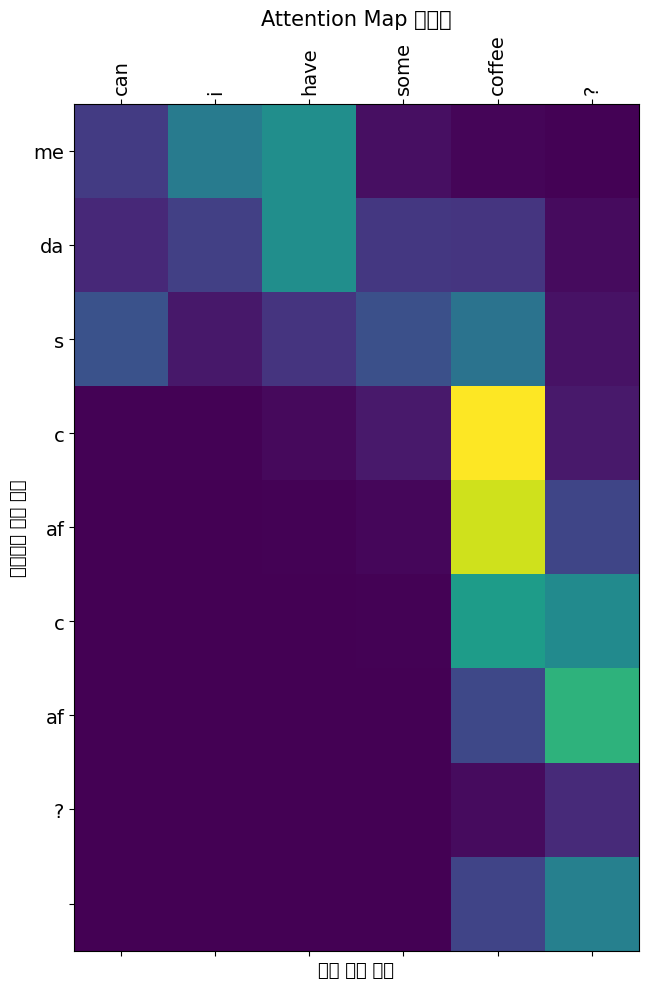

In [42]:
# ============================
# 🌍 번역 테스트 3탄!
# ============================

translate(
    "Can I have some coffee?",
    model,
    encoder_tokenizer,
    decoder_tokenizer,
    max_len=30
)

 프로젝트 : Seq2Seq으로 한국어 번역기 만들기

In [46]:
# ============================
# 📦 라이브러리 버전 확인
# ============================
# 프로젝트 시작 전에 사용할 라이브러리 버전 체크!
# 버전에 따라 코드가 다르게 동작할 수 있으니 꼭 확인해요 😊

import pandas
import torch
import matplotlib

print(pandas.__version__)      # pandas 버전
print(torch.__version__)       # PyTorch 버전
print(matplotlib.__version__)  # matplotlib 버전

2.2.2
2.10.0+cu128
3.10.0


In [47]:
# 현재 노트북을 새 폴더로 복사
!cp "/content/drive/MyDrive/Seq2seq으로 번역기 만들기 [프로젝트].ipynb" \
    "/content/work/kor_eng_translator/Seq2Seq으로 한국어 번역기 만들기.ipynb"
print("저장 완료! ✅")

cp: cannot stat '/content/drive/MyDrive/Seq2seq으로 번역기 만들기 [프로젝트].ipynb': No such file or directory
저장 완료! ✅


사전 준비

In [49]:
# ============================
# 📦 사전 준비 - 설치 및 폰트 설정
# ============================

# 한국어 형태소 분석기 (MeCab) 설치
!pip install konlpy
!pip install mecab-python3
!apt-get install -y fonts-nanum
!pip install sentencepiece

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 127 not upgraded.


In [50]:
# ============================
# 📚 라이브러리 불러오기
# ============================

import os
import re
import urllib.request
import tarfile                          # .tar.gz 압축 해제
import sentencepiece as spm
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

# 폰트 경고 메시지 숨기기
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 한국어 폰트 설정 (Attention Map 한글 깨짐 방지!)
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"설정된 폰트: {fontprop.get_name()}")
print(f"사용 장치: {device}")
print("준비 완료! ✅")

설정된 폰트: NanumBarunGothic
사용 장치: cuda
준비 완료! ✅


Step 1. 데이터 다운로드

In [51]:
# ============================
# 📥 Step 1. 데이터 다운로드
# ============================
# GitHub에서 한국어-영어 병렬 데이터 다운로드!
# korean-english-park.train.tar.gz 파일 사용

# 저장 폴더 생성
dataset_dir = "/content/work/프로젝트 : Seq2Seq으로 한국어 번역기 만들기/datasets"
os.makedirs(dataset_dir, exist_ok=True)

# 다운로드 URL
url = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

# 파일이 없을 때만 다운로드 (중복 방지!)
if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료! ✅")
else:
    print("이미 다운로드된 파일 존재! ✅")

# .tar.gz 압축 해제
print("압축 해제 중...")
with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(dataset_dir)
print("압축 해제 완료! ✅")

# 파일 목록 확인
print("\n데이터셋 파일 목록:")
for f in os.listdir(dataset_dir):
    print(f"  - {f}")

데이터 다운로드 중...
다운로드 완료! ✅
압축 해제 중...


/tmp/ipykernel_952/3765500512.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dataset_dir)


압축 해제 완료! ✅

데이터셋 파일 목록:
  - korean-english-park.train.ko
  - korean-english-park.train.tar.gz
  - korean-english-park.train.en


In [52]:
# ============================
# 👀 데이터 확인
# ============================
# 한국어 파일과 영어 파일을 각각 읽어서 확인!

kor_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
eng_path = os.path.join(dataset_dir, "korean-english-park.train.en")

# 파일 읽기
with open(kor_path, 'r', encoding='utf-8') as f:
    kor_lines = f.readlines()

with open(eng_path, 'r', encoding='utf-8') as f:
    eng_lines = f.readlines()

print(f"한국어 문장 수: {len(kor_lines):,}개")
print(f"영어 문장 수: {len(eng_lines):,}개")
print("\n샘플 데이터:")
for i in range(5):
    print(f"  한국어: {kor_lines[i].strip()}")
    print(f"  영어  : {eng_lines[i].strip()}")
    print()

한국어 문장 수: 94,123개
영어 문장 수: 94,123개

샘플 데이터:
  한국어: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
  영어  : Much of personal computing is about "can you top this?"

  한국어: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
  영어  : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.

  한국어: 그러나 이것은 또한 책상도 필요로 하지 않는다.
  영어  : Like all optical mice, But it also doesn't need a desk.

  한국어: 79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
  영어  : uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.

  한국어: 정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.
  영어  : Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world's maritime trade is vulnerable 

Step 2. 데이터 정제

In [53]:
# ============================
# 🧹 Step 2-1. 중복 데이터 제거
# ============================
# set 자료형 → 중복 허용 X 특성 활용!
# 병렬 쌍이 흐트러지지 않도록 튜플로 묶어서 처리 😊

# 줄바꿈 제거
kor_lines = [line.strip() for line in kor_lines]
eng_lines = [line.strip() for line in eng_lines]

# 튜플로 묶어서 set으로 중복 제거
corpus_pairs = list(set(zip(kor_lines, eng_lines)))

print(f"중복 제거 전: {len(kor_lines):,}개")
print(f"중복 제거 후: {len(corpus_pairs):,}개")
print(f"제거된 중복 수: {len(kor_lines) - len(corpus_pairs):,}개")

중복 제거 전: 94,123개
중복 제거 후: 78,941개
제거된 중복 수: 15,182개


In [54]:
# ============================
# 🧹 Step 2-2. 문장 전처리 함수 정의
# ============================
# 영어 + 한국어 모두 처리할 수 있도록
# 기존 함수에 한글 정규식 추가! 😊

def preprocess_sentence(sentence, is_korean=False):

    # 앞뒤 공백 제거
    sentence = sentence.strip()

    if is_korean:
        # 한국어 전처리
        # 한글, 영문, 숫자, 기본 구두점만 허용
        sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
        sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,\s]", " ", sentence)
        sentence = re.sub(r"\s+", " ", sentence)
    else:
        # 영어 전처리 (기존과 동일)
        sentence = sentence.lower()
        sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
        sentence = re.sub(r'[" "]+', " ", sentence)
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()
    return sentence

# 테스트
print(preprocess_sentence("오바마는 대통령이다!", is_korean=True))
print(preprocess_sentence("Obama is the president!"))
print("전처리 함수 정의 완료! ✅")

오바마는 대통령이다 !
obama is the president !
전처리 함수 정의 완료! ✅


In [55]:
# ============================
# 🧹 Step 2-3. 전처리 적용 + 길이 필터링
# ============================
# 토큰 길이 40 이하인 데이터만 선별!
# 너무 긴 문장은 학습을 어렵게 만들어요 😊

kor_corpus = []
eng_corpus = []

for kor, eng in corpus_pairs:
    # 전처리 적용
    kor_clean = preprocess_sentence(kor, is_korean=True)
    eng_clean = preprocess_sentence(eng, is_korean=False)

    # 빈 문장 제외
    if not kor_clean or not eng_clean:
        continue

    # 토큰 길이 40 이하인 데이터만 선별
    if len(kor_clean.split()) <= 40 and len(eng_clean.split()) <= 40:
        kor_corpus.append(kor_clean)
        eng_corpus.append(eng_clean)

print(f"필터링 후 데이터 수: {len(kor_corpus):,}개")
print("\n샘플 확인:")
for i in range(3):
    print(f"  한국어: {kor_corpus[i]}")
    print(f"  영어  : {eng_corpus[i]}")
    print()

필터링 후 데이터 수: 72,102개

샘플 확인:
  한국어: 현 경제 상황이 미국인의 긴축재정을 가중시키고 있는 가운데 일부 미국인은 독창적인 방법으로 매달 수익을 올리고 있다 .
  영어  : with the economy squeezing the budgets of more americans , some people are looking for creative ways to pay their monthly bills .

  한국어: 소렌스탐은 누구에게나 가족이 우선일 것이고 특별히 그녀가 화목한 가정을 이루고 있다는 사실을 안다 며 그녀의 결정을 존중하고 싶다 고 말했다 .
  영어  : that being said , family comes first and i know she has a very close family . i respect and support her decision and wish them the best .

  한국어: 레바논 수도 베이루트에서 13일 현지시간 폭탄테러가 발생 , 반 시리아파 의원이 사망했다 .
  영어  : beirut , lebanon cnn a member of the lebanese parliament died in a beirut bomb blast wednesday the latest anti syrian politician to be killed in the country .



Step 3. 데이터 토큰화

In [56]:
# ============================
# 📝 Step 3-1. 텍스트 파일 저장
# ============================
# SentencePiece 학습을 위해 txt 파일로 저장!

kor_txt_path = os.path.join(dataset_dir, "kor_corpus.txt")
eng_txt_path = os.path.join(dataset_dir, "eng_corpus.txt")

with open(kor_txt_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(kor_corpus))

with open(eng_txt_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(eng_corpus))

print("텍스트 파일 저장 완료! ✅")
print(f"  한국어: {kor_txt_path}")
print(f"  영어  : {eng_txt_path}")

텍스트 파일 저장 완료! ✅
  한국어: /content/work/프로젝트 : Seq2Seq으로 한국어 번역기 만들기/datasets/kor_corpus.txt
  영어  : /content/work/프로젝트 : Seq2Seq으로 한국어 번역기 만들기/datasets/eng_corpus.txt


In [57]:
# ============================
# 🔤 Step 3-2. SentencePiece Tokenizer 학습
# ============================
# 한국어(인코더)와 영어(디코더) Tokenizer 각각 학습!
# vocab_size 최소 10,000 이상으로 설정 😊

vocab_size = 10000   # 단어 사전 크기
pad_id = 0           # <pad>
bos_id = 1           # <start>
eos_id = 2           # <end>
unk_id = 3           # <unk>

# 한국어 Tokenizer (인코더용)
spm.SentencePieceTrainer.train(
    input=kor_txt_path,
    model_prefix=os.path.join(dataset_dir, "encoder_spm"),
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id,
    character_coverage=0.9995,  # 한국어는 높게 설정!
    model_type='bpe'            # BPE 방식 사용
)

# 영어 Tokenizer (디코더용)
spm.SentencePieceTrainer.train(
    input=eng_txt_path,
    model_prefix=os.path.join(dataset_dir, "decoder_spm"),
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id,
    character_coverage=1.0,
    model_type='bpe'
)

print("Tokenizer 학습 완료! ✅")

Tokenizer 학습 완료! ✅


In [58]:
# ============================
# 🔤 Step 3-2. SentencePiece Tokenizer 학습
# ============================
# 한국어(인코더)와 영어(디코더) Tokenizer 각각 학습!
# vocab_size 최소 10,000 이상으로 설정 😊

vocab_size = 10000   # 단어 사전 크기
pad_id = 0           # <pad>
bos_id = 1           # <start>
eos_id = 2           # <end>
unk_id = 3           # <unk>

# 한국어 Tokenizer (인코더용)
spm.SentencePieceTrainer.train(
    input=kor_txt_path,
    model_prefix=os.path.join(dataset_dir, "encoder_spm"),
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id,
    character_coverage=0.9995,  # 한국어는 높게 설정!
    model_type='bpe'            # BPE 방식 사용
)

# 영어 Tokenizer (디코더용)
spm.SentencePieceTrainer.train(
    input=eng_txt_path,
    model_prefix=os.path.join(dataset_dir, "decoder_spm"),
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id,
    character_coverage=1.0,
    model_type='bpe'
)

print("Tokenizer 학습 완료! ✅")

Tokenizer 학습 완료! ✅


In [59]:
# ============================
# 📂 Step 3-3. Tokenizer 로드 & 데이터 변환
# ============================

# Tokenizer 불러오기
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load(os.path.join(dataset_dir, "encoder_spm.model"))

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load(os.path.join(dataset_dir, "decoder_spm.model"))

print(f"한국어 vocab 크기: {len(encoder_tokenizer):,}")
print(f"영어 vocab 크기  : {len(decoder_tokenizer):,}")

# 토큰화 테스트
test_kor = kor_corpus[0]
test_eng = eng_corpus[0]
print(f"\n한국어 원문: {test_kor}")
print(f"토큰화 결과: {encoder_tokenizer.encode(test_kor)}")
print(f"\n영어 원문  : {test_eng}")
print(f"토큰화 결과: {decoder_tokenizer.encode(test_eng)}")

한국어 vocab 크기: 10,000
영어 vocab 크기  : 10,000

한국어 원문: 현 경제 상황이 미국인의 긴축재정을 가중시키고 있는 가운데 일부 미국인은 독창적인 방법으로 매달 수익을 올리고 있다 .
토큰화 결과: [57, 353, 2707, 67, 1046, 981, 9161, 8925, 777, 8632, 2272, 73, 769, 407, 67, 217, 268, 9307, 134, 4189, 7174, 5264, 158, 312, 22, 4]

영어 원문  : with the economy squeezing the budgets of more americans , some people are looking for creative ways to pay their monthly bills .
토큰화 결과: [107, 9, 1199, 8811, 5055, 9, 4291, 9976, 38, 246, 1862, 16, 390, 241, 150, 2170, 67, 2980, 191, 3599, 34, 1483, 242, 7556, 6363, 13]


In [60]:
# ============================
# 📦 Step 3-4. Dataset & DataLoader 생성
# ============================

MAX_LEN   = 40    # 최대 문장 길이
BATCH_SIZE = 64   # 배치 크기

class TranslationDataset(Dataset):
    def __init__(self, kor_data, eng_data,
                 encoder_tokenizer, decoder_tokenizer, max_len):
        self.kor_data = kor_data
        self.eng_data = eng_data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id  = 0
        self.bos_id  = 1
        self.eos_id  = 2

    def __len__(self):
        return len(self.kor_data)

    def __getitem__(self, idx):
        # 한국어(소스) → 인코더 입력
        src_ids = self.encoder_tokenizer.encode(self.kor_data[idx])
        src_ids = src_ids[:self.max_len]

        # 영어(타겟) → 디코더 입력/라벨
        trg_ids = self.decoder_tokenizer.encode(self.eng_data[idx])

        # 디코더 입력: <start> + 문장 + <end>
        trg_input = [self.bos_id] + trg_ids[:self.max_len-2] + [self.eos_id]

        # 디코더 라벨: 문장 + <end>
        trg_label = trg_ids[:self.max_len-1] + [self.eos_id]

        # 패딩 추가
        src_ids   = src_ids   + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return (torch.tensor(src_ids),
                torch.tensor(trg_input),
                torch.tensor(trg_label))

# 주의: 검증 데이터 분리 없이 전체 사용!
dataset    = TranslationDataset(kor_corpus, eng_corpus,
                                 encoder_tokenizer, decoder_tokenizer,
                                 max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"전체 데이터 수: {len(dataset):,}개")
print(f"배치 수       : {len(train_loader):,}개")
print("DataLoader 생성 완료! ✅")

전체 데이터 수: 72,102개
배치 수       : 1,127개
DataLoader 생성 완료! ✅


Step 4. 모델 설계

In [61]:
# ============================
# 🎯 Step 4-1. Bahdanau Attention
# ============================

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # 인코더 hidden state 변환 (Uₐ)
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        # 디코더 hidden state 변환 (Wₐ)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        # 스칼라 점수 변환 (vₐ)
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]

        # 디코더 hidden을 src_len번 복사
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        # shape 맞추기
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # Attention Score 계산
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)

        return nn.functional.softmax(attention, dim=1)

In [62]:
# ============================
# 📥 Step 4-2. Encoder
# ============================

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        # 토큰 ID → 임베딩 벡터
        self.embedding = nn.Embedding(input_dim, emb_dim)
        # GRU: 한국어 문장 처리
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src: (src_len, batch_size)
        embedded = self.embedding(src)
        # embedded: (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)
        # outputs: (src_len, batch_size, hidden_dim)
        # hidden : (1, batch_size, hidden_dim)
        return outputs, hidden

In [63]:
# ============================
# 📤 Step 4-3. Decoder
# ============================

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention  = attention
        self.embedding  = nn.Embedding(output_dim, emb_dim)
        # GRU 입력 = 임베딩만
        self.rnn    = nn.GRU(emb_dim, hidden_dim)
        # 출력층 = hidden + context 결합
        self.fc_out = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input: (batch_size,)
        input    = input.unsqueeze(0)        # (1, batch_size)
        embedded = self.embedding(input)     # (1, batch_size, emb_dim)

        # Attention 가중치 계산
        a = self.attention(hidden[-1], encoder_outputs)
        # a: (batch_size, src_len)

        # Context Vector 계산
        a               = a.unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context         = torch.bmm(a, encoder_outputs)
        context         = context.permute(1, 0, 2)
        # context: (1, batch_size, hidden_dim)

        # GRU 실행
        output, hidden = self.rnn(embedded, hidden)

        # hidden + context 결합 → 단어 예측
        output     = output.squeeze(0)
        context    = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        # prediction: (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [64]:
# ============================
# 🤝 Step 4-4. Seq2Seq 전체 모델
# ============================

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg=None, max_len=40, bos_id=1, eos_id=2):
        batch_size = src.shape[1]
        outputs    = []
        attentions = []

        # 인코더 실행
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # 학습 모드: Teacher Forcing
            for t in range(trg.shape[0]):
                output, hidden, attention = self.decoder(
                    trg[t], hidden, encoder_outputs
                )
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # 추론 모드: <start> 토큰으로 시작
            input    = torch.full((batch_size,), bos_id,
                                   dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size,
                                    dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(
                    input, hidden, encoder_outputs
                )
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                top1     = output.argmax(1)
                input    = top1
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs    = torch.cat(outputs,    dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions

In [65]:
# ============================
# ⚙️ Step 4-5. 모델 생성
# ============================

input_dim  = len(encoder_tokenizer)   # 한국어 vocab
output_dim = len(decoder_tokenizer)   # 영어 vocab
emb_dim    = 256
hid_dim    = 512

attention = BahdanauAttention(hid_dim).to(device)
encoder   = Encoder(input_dim, emb_dim, hid_dim).to(device)
decoder   = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model     = Seq2SeqAttention(encoder, decoder, device).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\n학습 가능한 파라미터 수: {total_params:,}개")

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=10000, bias=True)
  )
)

학습 가능한 파라미터 수: 18,261,264개


Step 5. 훈련하기

In [66]:
# ============================
# ⚙️ Step 5-1. Optimizer & Loss
# ============================

optimizer = optim.Adam(model.parameters(), lr=1e-3)
# PAD 토큰(0) 무시하고 Loss 계산!
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
print("슝~")

슝~


In [67]:
# ============================
# 🏋️ Step 5-2. train_step 함수
# ============================

def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # (batch, seq) → (seq, batch)
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)

        # shape 변환
        outputs   = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        # Exploding Gradient 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")

슝~


In [68]:
# ============================
# 🌍 Step 5-3. 번역 평가 함수
# ============================

def preprocess_korean(sentence):
    return preprocess_sentence(sentence, is_korean=True)

def evaluate(sentence, model, encoder_tokenizer,
             decoder_tokenizer, max_len=40):
    model.eval()
    sentence = preprocess_korean(sentence)

    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))

    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [
        decoder_tokenizer.decode([token.item()])
        for token in outputs.argmax(2).squeeze(1)
    ]
    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()


def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')
    fontdict = {'fontsize': 14}
    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)
    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)
    ax.set_xlabel('한국어 입력', fontsize=13)
    ax.set_ylabel('영어 번역', fontsize=13)
    ax.set_title('Attention Map', fontsize=15)
    plt.tight_layout()
    plt.show()


def translate(sentence, model, encoder_tokenizer,
              decoder_tokenizer, max_len=40):
    result, src, attention = evaluate(
        sentence, model,
        encoder_tokenizer, decoder_tokenizer, max_len
    )
    print(f'Input   : {src}')
    print(f'Output  : {" ".join(result)}')

    attention = attention[:len(result), :len(src.split())]
    plot_attention(attention, src.split(), result)

In [70]:
# ============================
# 🚀 Step 5-4. 훈련 시작!
# ============================

EPOCHS = 30
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    train_loss = train_step(
        model, train_loader, optimizer, criterion, epoch
    )
    print(f'\nEpoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

    # 5 에폭마다 번역 결과 확인
    if (epoch + 1) % 5 == 0:
        print("\n===== 번역 결과 확인 =====")
        for sent in test_sentences:
            result, src, _ = evaluate(
                sent, model,
                encoder_tokenizer, decoder_tokenizer
            )
            print(f"  입력: {src}")
            print(f"  출력: {' '.join(result)}")
            print()

Epoch 1: 100%|██████████| 1127/1127 [04:26<00:00,  4.23it/s, loss=4.79]



Epoch 1/30, Train Loss: 5.3871


Epoch 2: 100%|██████████| 1127/1127 [04:41<00:00,  4.00it/s, loss=3.98]



Epoch 2/30, Train Loss: 4.1454


Epoch 3: 100%|██████████| 1127/1127 [04:41<00:00,  4.00it/s, loss=3.6]


...


Epoch 28/30, Train Loss: 0.8468


Epoch 29: 100%|██████████| 1127/1127 [04:39<00:00,  4.03it/s, loss=0.956]



Epoch 29/30, Train Loss: 0.8382


Epoch 30: 100%|██████████| 1127/1127 [04:40<00:00,  4.02it/s, loss=1]



Epoch 30/30, Train Loss: 0.8298

===== 번역 결과 확인 =====
  입력: 오바마는 대통령이다 .
  출력: obama is my ing . 

  입력: 시민들은 도시 속에 산다 .
  출력: the city s historic city panel stood bes ides . 

  입력: 커피는 필요 없다 .
  출력: coffee there is no need for alternative children with the need y 

  입력: 일곱 명의 사망자가 발생했다 .
  출력: seven others were injured . 



===== 최종 번역 결과 =====

Input   : 오바마는 대통령이다 .
Output  : obama is my ing . 


/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

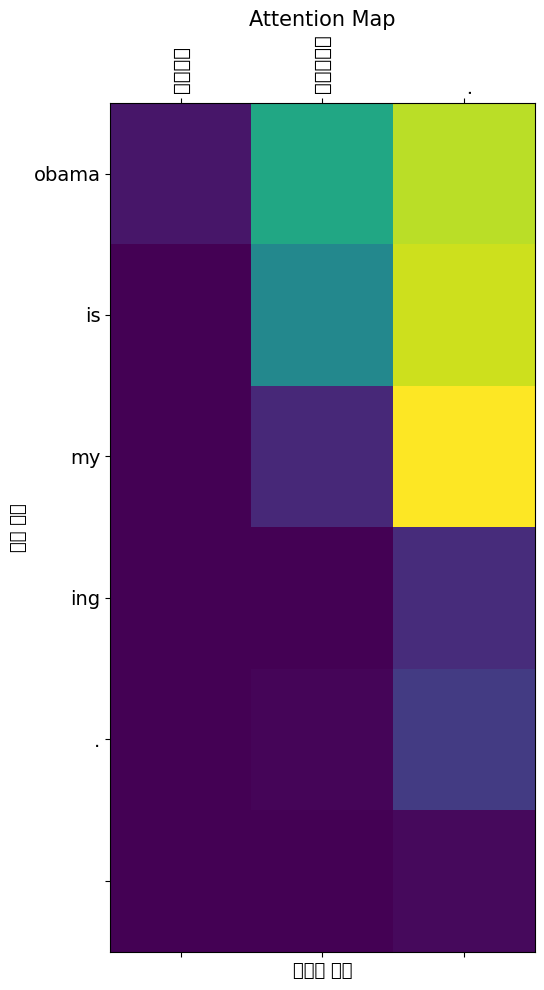

--------------------------------------------------
Input   : 시민들은 도시 속에 산다 .
Output  : the city s historic city panel stood bes ides . 


/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

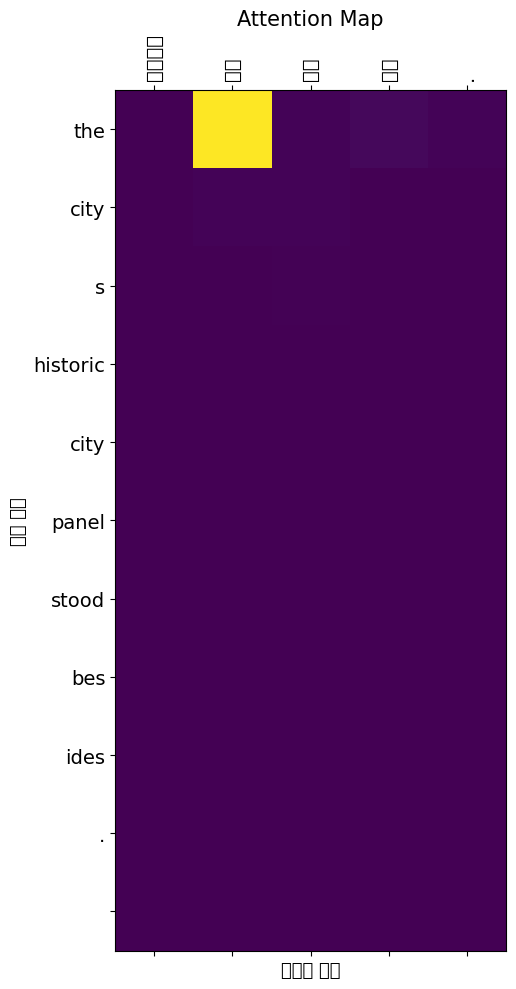

--------------------------------------------------


/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Input   : 커피는 필요 없다 .
Output  : coffee there is no need for alternative children with the need y 


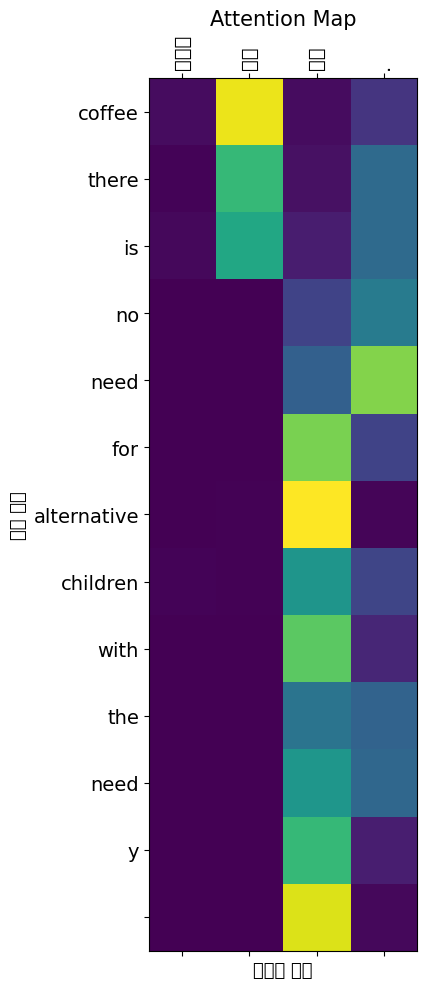

--------------------------------------------------
Input   : 일곱 명의 사망자가 발생했다 .
Output  : seven others were injured . 


/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_952/2119472094.py:43: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

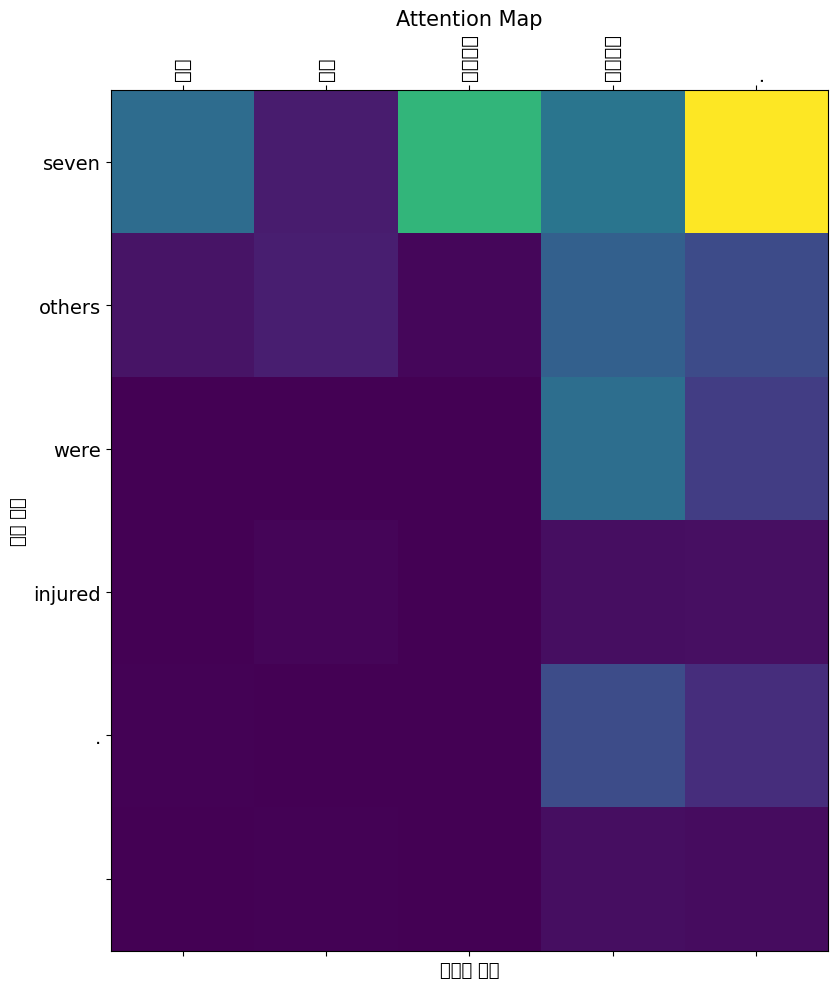

--------------------------------------------------


In [71]:
# ============================
# 📊 최종 번역 결과 + Attention Map
# ============================

print("===== 최종 번역 결과 =====\n")
for sent in test_sentences:
    translate(sent, model, encoder_tokenizer, decoder_tokenizer)
    print("-" * 50)